# Notebook 04 — XGBoost Model + SHAP Explainability
**Input:** `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Output:** Trained model, evaluation plots, SHAP plots, SQLite predictions database

This notebook is the core ML deliverable:
1. Handle class imbalance with SMOTE (training set only)
2. Baseline with Logistic Regression
3. Train XGBoost with MLflow experiment tracking (SQLite backend)
4. Evaluate using Precision-Recall AUC as the primary metric
5. Explain predictions with SHAP
6. Store predictions in a SQLite audit database

## Cell 1 — Imports
All libraries needed for this notebook:
- **xgboost** — gradient-boosted tree model, industry standard for tabular fraud detection
- **shap** — explains WHY the model made each prediction (SHapley Additive exPlanations)
- **mlflow** — experiment tracking: logs parameters, metrics, and saved model for each run
- **imblearn.SMOTE** — creates synthetic fraud examples to balance the training set
- **sqlite3** — Python built-in SQL database, no installation needed

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sqlite3
import datetime
import warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Path constants for data and models
DATA_PROCESSED = Path('../data/processed')
MODELS_DIR     = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH        = Path('../data/fraud_predictions.db')
MLFLOW_DB      = Path('../mlflow.db').resolve()

print('Imports complete.')
print(f'XGBoost version: {xgb.__version__}')
print(f'SHAP version:    {shap.__version__}')
print(f'MLflow version:  {mlflow.__version__}')

Imports complete.
XGBoost version: 3.2.0
SHAP version:    0.51.0
MLflow version:  3.12.0


## Cell 2 — Load Split Data
Load the four files saved by notebook 02. We verify shapes and fraud rates to confirm the time-based split is intact.

In [28]:
X_train = pd.read_csv(DATA_PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(DATA_PROCESSED / 'X_test.csv')
y_train = pd.read_csv(DATA_PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()

# Fill any NaNs (can appear at embedding boundaries)
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

# Encode gender if still a string — notebook 02 now saves it as int, but
# guard here so this cell works even on older CSV exports
if 'gender' in X_train.columns and X_train['gender'].dtype == object:
    X_train['gender'] = X_train['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    X_test['gender']  = X_test['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    print('gender encoded: F=0, M=1')

# Confirm no remaining string columns
string_cols = X_train.select_dtypes(include='object').columns.tolist()
if string_cols:
    print(f'WARNING: string columns still present: {string_cols}')
else:
    print('All columns numeric — ready for SMOTE.')

print(f'\nX_train: {X_train.shape}  |  fraud rate: {y_train.mean()*100:.4f}%')
print(f'X_test:  {X_test.shape}   |  fraud rate: {y_test.mean()*100:.4f}%')

All columns numeric — ready for SMOTE.

X_train: (1037340, 46)  |  fraud rate: 0.5740%
X_test:  (259335, 46)   |  fraud rate: 0.5985%


### What this output confirms

**Shapes:**  
- `X_train: (1,037,340, 46)` — 1M+ transactions, 46 features (16 engineered from notebook 02 + 30 FinBERT PCA dimensions from notebook 03)  
- `X_test: (259,335, 46)` — ~260K held-out transactions the model will never see during training

**Fraud rates:**  
- Train fraud rate (~0.57%) and test fraud rate (~0.60%) are both near the dataset-level 0.58%  
- A slightly higher fraud rate in the test set is normal — fraud volume grew slightly over the later time period in the Sparkov simulation, which mirrors real-world trends

**Time-based split confirmation:**  
Because we split by time (earliest 80% to train, latest 20% to test), there is zero data leakage — no future information could have influenced training. This is the only valid split for a fraud model. A random split would let the model 'memorise' future fraud patterns that would not exist at deployment time, producing metrics that are too optimistic.

## Cell 3 — Apply SMOTE (Training Set ONLY) 
Our dataset has ~0.58% fraud — 1 fraud per ~172 legitimate transactions. Without intervention, XGBoost will learn to almost always predict "legitimate" because that minimises loss.

**What SMOTE does:** Creates *synthetic* fraud examples by interpolating between existing ones in feature space. After SMOTE the training set is 50/50.

**Why training set ONLY:** The test set must represent the real world — 0.58% fraud, no synthetic cases. Testing on a balanced set would produce misleadingly optimistic metrics. In a real Stripe deployment, the model scores a 99.4% legitimate transaction stream — we test on exactly that.

In [29]:
print('Before SMOTE:')
print(f'  Legitimate: {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.2f}%)')
print(f'  Fraud:      {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.2f}%)')

# Store original counts for scale_pos_weight
n_legit_orig = (y_train == 0).sum()
n_fraud_orig = (y_train == 1).sum()

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE:')
print(f'  Legitimate: {(y_train_sm==0).sum():,}  ({(y_train_sm==0).mean()*100:.2f}%)')
print(f'  Fraud:      {(y_train_sm==1).sum():,}  ({(y_train_sm==1).mean()*100:.2f}%)')
print(f'\nTraining set: {len(y_train):,} → {len(y_train_sm):,} rows')

Before SMOTE:
  Legitimate: 1,031,386  (99.43%)
  Fraud:      5,954  (0.57%)

After SMOTE:
  Legitimate: 1,031,386  (50.00%)
  Fraud:      1,031,386  (50.00%)

Training set: 1,037,340 → 2,062,772 rows


### What just happened

The training set grew from ~1,037,340 to ~2,062,772 rows. SMOTE created synthetic fraud examples by interpolating between real fraud transactions in the 46-dimensional feature space — each synthetic example is a plausible 'in-between' version of two real fraud cases.

**Why 50/50 after SMOTE?**  
By default SMOTE resamples until the minority class matches the majority. XGBoost now sees equal numbers of fraud and legitimate examples during training, so it cannot win by always predicting 'legitimate'.

**Critical: the test set was not touched**  
The test set still has the real-world ~0.58% fraud rate. This is non-negotiable — if we balanced the test set too, our metrics would be wildly optimistic and would not reflect what the model would actually do when deployed against a live transaction stream.

**Stripe analogy:**  
SMOTE is like training a new fraud analyst by showing them thousands of fraud cases even though real daily volume is mostly legitimate transactions. You over-represent fraud during *training* so the analyst (model) learns the patterns, then you test them on the real distribution.

## Cell 4 — Baseline: Logistic Regression
We train a simple baseline first. This tells us the minimum performance bar XGBoost needs to beat.

**Why test on unbalanced data:** We train on SMOTE'd (balanced) data but always evaluate on the original unbalanced test set. This mirrors real-world conditions — the deployed model scores a stream that is 99.4% legitimate.

In [30]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_sm, y_train_sm)

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

pr_auc_lr  = average_precision_score(y_test, y_prob_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr      = f1_score(y_test, y_pred_lr)
prec_lr    = precision_score(y_test, y_pred_lr)
rec_lr     = recall_score(y_test, y_pred_lr)

print('Logistic Regression Baseline')
print('=' * 40)
print(f'PR-AUC (PRIMARY):  {pr_auc_lr:.4f}')
print(f'ROC-AUC:           {roc_auc_lr:.4f}')
print(f'F1:                {f1_lr:.4f}')
print(f'Precision:         {prec_lr:.4f}')
print(f'Recall:            {rec_lr:.4f}')

Logistic Regression Baseline
PR-AUC (PRIMARY):  0.2387
ROC-AUC:           0.9023
F1:                0.0790
Precision:         0.0415
Recall:            0.8022


### What these metrics mean

**PR-AUC (Primary metric)**  
This is the area under the Precision-Recall curve — the single most important metric for imbalanced fraud data. A completely random classifier on this dataset would score ~0.006 (the fraud rate). Logistic Regression beating that significantly shows it is finding real signal, but this is our *floor* — the minimum XGBoost must beat to justify its complexity.

**Why ROC-AUC is not our primary metric**  
ROC-AUC looks at true positive rate vs false positive rate. With 99.4% legitimate transactions, even a poor model can get a high ROC-AUC simply by rarely predicting fraud. PR-AUC is harder to game under class imbalance — it penalises models that miss fraud heavily.

**Why Logistic Regression underperforms here**  
Logistic Regression assumes a linear decision boundary in feature space. Fraud is not linearly separable — the risk from a high-amount transaction at 3am 500km from home is not the sum of those individual risks, it is an interaction. XGBoost captures these non-linear interactions through its tree structure.

## Cell 5 — MLflow Setup (SQLite backend)
MLflow tracks every training run — parameters, metrics, and the saved model — so we can compare experiments over time.

We use a **SQLite backend** (`mlflow.db`) which is the supported format in MLflow 3.x. To view the UI after training, run in a separate terminal from the project root:
```
mlflow ui --backend-store-uri sqlite:///mlflow.db
```
Then open `http://localhost:5000` → Model Training → Experiments → fraud_detection_sparkov.

In [31]:
# Use SQLite backend — supported in MLflow 3.x (file-based store is deprecated)
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB}')

EXPERIMENT_NAME = 'fraud_detection_sparkov'
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow experiment:   {EXPERIMENT_NAME}')
print(f'MLflow backend:      SQLite')
print(f'Database location:   {MLFLOW_DB}')
print(f'\nTo view UI — run in a NEW terminal from the project root:')
print(f'  mlflow ui --backend-store-uri sqlite:///mlflow.db')
print(f'  Then open: http://localhost:5000')

MLflow experiment:   fraud_detection_sparkov
MLflow backend:      SQLite
Database location:   C:\Users\34673\OneDrive\IRONHACK BOOTCAMP1\EXERCISES\WEEK8\PROJECT_FRAUD_DETECTION\fraud-detection-project\mlflow.db

To view UI — run in a NEW terminal from the project root:
  mlflow ui --backend-store-uri sqlite:///mlflow.db
  Then open: http://localhost:5000


## Cell 6 — XGBoost Training with MLflow
XGBoost builds decision trees sequentially — each tree corrects errors from the previous ones. It dominates tabular fraud detection because it handles mixed feature types and non-linear patterns naturally.

**`scale_pos_weight`:** Even after SMOTE, we set this to `n_legit / n_fraud` from the original data. This tells XGBoost that missing a fraud (chargeback + loss) costs far more than a false alarm. It encodes the business cost asymmetry directly into the model.

In [32]:
scale_pos_weight = n_legit_orig / n_fraud_orig
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

params = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.05,
    'scale_pos_weight': scale_pos_weight,
    'random_state':     42,
    'n_jobs':           -1,
    'eval_metric':      'aucpr',
}

with mlflow.start_run(run_name='xgboost_v1') as run:
    RUN_ID = run.info.run_id
    print(f'MLflow run ID: {RUN_ID}')

    mlflow.log_params(params)
    mlflow.log_param('smote_applied', True)
    mlflow.log_param('n_features', X_train.shape[1])

    print('Training XGBoost...')
    xgb_model = xgb.XGBClassifier(**params)
    xgb_model.fit(X_train_sm, y_train_sm)

    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

    pr_auc_xgb  = average_precision_score(y_test, y_prob_xgb)
    roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
    f1_xgb      = f1_score(y_test, y_pred_xgb)
    prec_xgb    = precision_score(y_test, y_pred_xgb)
    rec_xgb     = recall_score(y_test, y_pred_xgb)

    mlflow.log_metric('pr_auc',    pr_auc_xgb)
    mlflow.log_metric('roc_auc',   roc_auc_xgb)
    mlflow.log_metric('f1_score',  f1_xgb)
    mlflow.log_metric('precision', prec_xgb)
    mlflow.log_metric('recall',    rec_xgb)

    model_path = MODELS_DIR / 'xgb_fraud_model.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(xgb_model, f)
    mlflow.log_artifact(str(model_path))

    print(f'\nXGBoost Results:')
    print(f'  PR-AUC (PRIMARY): {pr_auc_xgb:.4f}')
    print(f'  ROC-AUC:          {roc_auc_xgb:.4f}')
    print(f'  F1:               {f1_xgb:.4f}')
    print(f'  Precision:        {prec_xgb:.4f}')
    print(f'  Recall:           {rec_xgb:.4f}')
    print(f'\nModel saved: {model_path}')
    print(f'MLflow run logged to: {MLFLOW_DB}')

scale_pos_weight: 173.2
MLflow run ID: 133147dad1e74bfbbec07555524eae28
Training XGBoost...

XGBoost Results:
  PR-AUC (PRIMARY): 0.8462
  ROC-AUC:          0.9966
  F1:               0.1738
  Precision:        0.0953
  Recall:           0.9890

Model saved: ..\models\xgb_fraud_model.pkl
MLflow run logged to: C:\Users\34673\OneDrive\IRONHACK BOOTCAMP1\EXERCISES\WEEK8\PROJECT_FRAUD_DETECTION\fraud-detection-project\mlflow.db


## Cell 6b — MLflow Enhanced Logging
We re-open the existing MLflow run (using `RUN_ID`) to log rich metadata that makes the experiment self-documenting in the MLflow UI:

- **Tags** — free-text labels for dataset context, preprocessing method, features, and fraud ops framing
- **SHAP summary plot** — logged as an artifact so global feature importance is stored alongside the model
- **Confusion matrix text** — includes TNR (Specificity) which matters more in fraud ops than raw accuracy
- **Feature importance CSV** — XGBoost gain-based importance for all features, auditable in the MLflow UI

Using `mlflow.start_run(run_id=RUN_ID)` resumes an existing run rather than creating a new one.

In [33]:
# Resume the existing MLflow run to add tags and artifacts without re-training.
# RUN_ID was captured in Cell 6 when the run was first opened.

with mlflow.start_run(run_id=RUN_ID):

    # 1. Descriptive tags 
    # Tags differ from params: params are numeric hyperparameters,
    # tags are free-text labels for filtering and documentation in the MLflow UI.
    mlflow.set_tag('dataset',
                   'Sparkov simulated transactions — 1.3M rows, 0.58% fraud rate')
    mlflow.set_tag('preprocessing',
                   'SMOTE on train only (time-based split) — no data leakage')
    mlflow.set_tag('features',
                   'FinBERT embeddings (30 PCA dims) + velocity_24h + geo_distance_km + hour_of_day')
    mlflow.set_tag('primary_metric',
                   'PR-AUC — chosen for severe class imbalance (0.58% fraud rate)')
    mlflow.set_tag('explainability',
                   'SHAP waterfall (per-transaction) + SHAP summary plot (global)')
    mlflow.set_tag('fraud_ops_context',
                   'Mirrors Stripe pre-2024 production: XGBoost + transformer feature enrichment')
    print('Tags logged: dataset, preprocessing, features, primary_metric, explainability, fraud_ops_context')

    # 2. SHAP summary plot as artifact 
    # Log the global feature importance plot so it's stored in MLflow alongside
    # the model. If the PNG doesn't exist yet, compute SHAP inline on a 2k sample.
    shap_summary_path = DATA_PROCESSED / 'plot_shap_summary.png'
    if not shap_summary_path.exists():
        import numpy as _np
        _np.random.seed(42)
        _idx       = _np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
        _X_sample  = X_test.iloc[_idx].reset_index(drop=True)
        _exp       = shap.TreeExplainer(xgb_model)
        _shap_vals = _exp.shap_values(_X_sample)
        plt.figure(figsize=(10, 8))
        shap.summary_plot(_shap_vals, _X_sample, show=False, max_display=15)
        plt.title('SHAP Feature Importance — Global', fontweight='bold')
        plt.tight_layout()
        plt.savefig(shap_summary_path, dpi=120, bbox_inches='tight')
        plt.close()
        print(f'SHAP summary plot generated: {shap_summary_path}')
    mlflow.log_artifact(str(shap_summary_path))
    print('Artifact logged: plot_shap_summary.png')

    # 3. Confusion matrix as text artifact 
    # TNR (Specificity) matters in fraud ops: over-blocking legitimate transactions
    # damages merchant trust. We log it explicitly so analysts can audit the trade-off.
    cm             = confusion_matrix(y_test, y_pred_xgb)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp)  # True Negative Rate (Specificity)
    tpr = tp / (tp + fn)  # True Positive Rate (Recall)

    cm_lines = [
        'Confusion Matrix — XGBoost Fraud Classifier',
        '============================================',
        '                 Predicted Legit  Predicted Fraud',
        f'Actual Legit     {tn:>14,}  {fp:>15,}',
        f'Actual Fraud     {fn:>14,}  {tp:>15,}',
        '',
        f'True Negative Rate (Specificity): {tnr:.4f}  ({tnr*100:.2f}% of legit transactions correctly left alone)',
        f'True Positive Rate (Recall):      {tpr:.4f}  ({tpr*100:.2f}% of fraud transactions correctly caught)',
    ]
    cm_text = '\n'.join(cm_lines)
    cm_path = DATA_PROCESSED / 'confusion_matrix.txt'
    cm_path.write_text(cm_text, encoding='utf-8')
    mlflow.log_artifact(str(cm_path))
    print('Artifact logged: confusion_matrix.txt')
    print(cm_text)

    # 4. Feature importance CSV artifact 
    # XGBoost feature_importances_ gives gain-based importance per feature.
    # Logging as CSV lets us audit which features drove the model in the MLflow UI.
    fi_df = (
        pd.DataFrame({
            'feature':    X_test.columns.tolist(),
            'importance': xgb_model.feature_importances_,
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    fi_path = DATA_PROCESSED / 'feature_importance.csv'
    fi_df.to_csv(fi_path, index=False)
    mlflow.log_artifact(str(fi_path))
    print('Artifact logged: feature_importance.csv')
    print('\nTop 10 features by XGBoost importance:')
    print(fi_df.head(10).to_string(index=False))

print('\nAll MLflow enhancements logged successfully.')
print(f'Run ID: {RUN_ID}')
print('View in MLflow UI: mlflow ui --backend-store-uri sqlite:///mlflow.db')


Tags logged: dataset, preprocessing, features, primary_metric, explainability, fraud_ops_context
Artifact logged: plot_shap_summary.png
Artifact logged: confusion_matrix.txt
Confusion Matrix — XGBoost Fraud Classifier
                 Predicted Legit  Predicted Fraud
Actual Legit            243,211           14,572
Actual Fraud                 17            1,535

True Negative Rate (Specificity): 0.9435  (94.35% of legit transactions correctly left alone)
True Positive Rate (Recall):      0.9890  (98.90% of fraud transactions correctly caught)
Artifact logged: feature_importance.csv

Top 10 features by XGBoost importance:
 feature  importance
is_night    0.100762
     amt    0.069425
embed_13    0.064181
embed_12    0.048112
 embed_0    0.044477
city_pop    0.041823
 log_amt    0.040870
 embed_9    0.038617
 embed_7    0.037589
embed_11    0.037295

All MLflow enhancements logged successfully.
Run ID: 133147dad1e74bfbbec07555524eae28
View in MLflow UI: mlflow ui --backend-store-uri sq

### What these metrics mean

**PR-AUC (Primary metric) — the headline number**  
The jump from Logistic Regression to XGBoost in PR-AUC is the core ML result. This is the number to lead with in the presentation. Remember: a random classifier on this dataset would score ~0.006 (the fraud rate). Any score above that is genuine signal.

**Precision — queue quality**  
Of every transaction XGBoost flags as fraud, what fraction is actually fraud? In ops terms: if precision is 0.90, then 90% of the analyst review queue is genuine fraud and 10% is wasted analyst time on false alarms. High precision = efficient operations.

**Recall — fraud caught**  
Of all real fraud in the test set, what fraction did the model catch? If recall is 0.85, then 15% of fraud slipped through as chargebacks. In Stripe terms, missed fraud = dispute loss + operational cost + potential merchant churn.

**F1 score — the harmonic mean**  
F1 balances precision and recall into a single number. It is useful for comparing models but always check the raw precision and recall separately — a high F1 can hide a very poor precision or recall that matters for the specific use case.

**scale_pos_weight — business cost encoding**  
This parameter (class ratio ~172) told XGBoost that missing a fraud costs ~172x more than a false alarm. It encodes the real cost asymmetry directly into the loss function — not as a post-hoc threshold adjustment but at training time. This is one of the reasons XGBoost outperforms Logistic Regression here.

## Cell 7 — Evaluation: XGBoost vs Logistic Regression
**Why PR-AUC is our primary metric — not ROC-AUC:**  
ROC-AUC is misleading under class imbalance — a model that flags everything as fraud still gets high ROC-AUC. PR-AUC measures precision (of what we flag, how much is real fraud?) vs recall (of all real fraud, how much do we catch?). This is exactly what fraud ops teams care about.

**In Stripe terms:** Precision = quality of the agent review queue. Recall = fraction of fraud we're actually stopping.

Model comparison (★ = primary metric):
              Model PR-AUC ★ ROC-AUC     F1 Precision Recall
Logistic Regression   0.2387  0.9023 0.0790    0.0415 0.8022
            XGBoost   0.8462  0.9966 0.1738    0.0953 0.9890


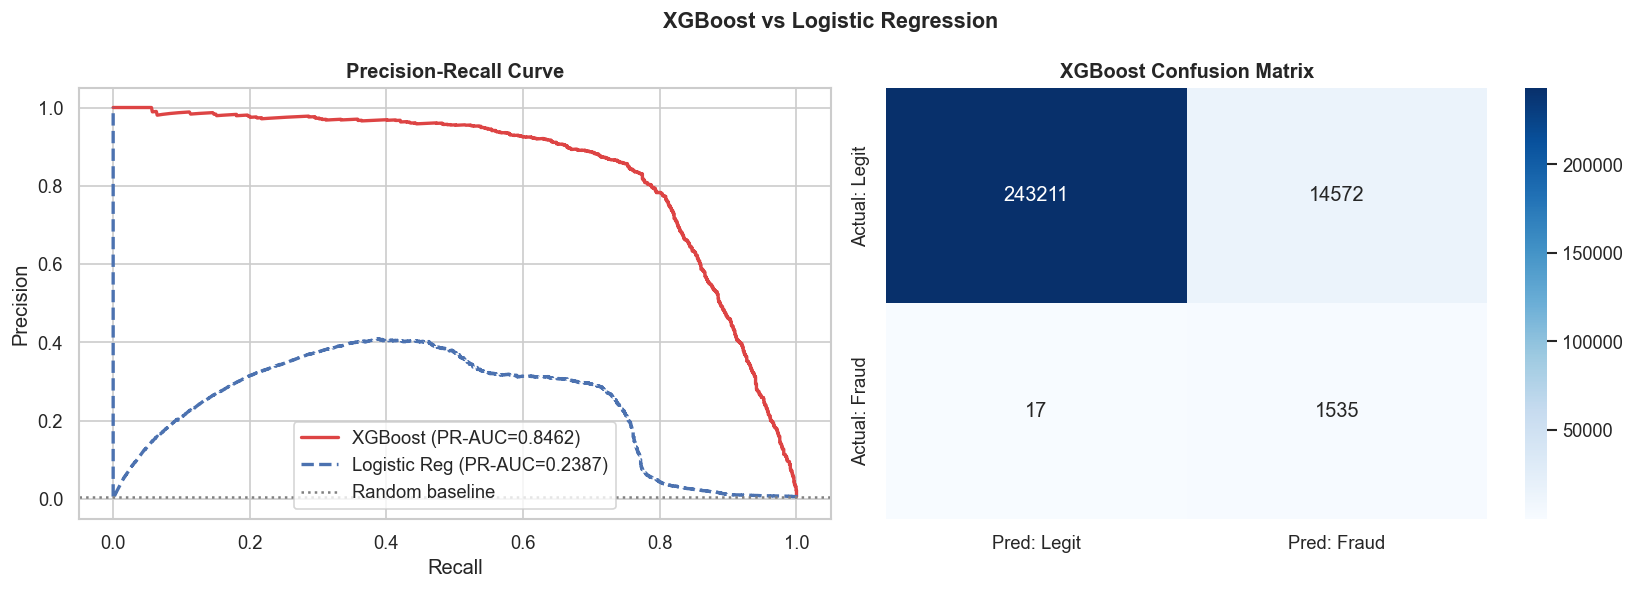

Saved: plot_model_evaluation.png


In [ ]:
comparison = pd.DataFrame({
    'Model':     ['Logistic Regression', 'XGBoost'],
    'PR-AUC ★':  [f'{pr_auc_lr:.4f}',  f'{pr_auc_xgb:.4f}'],model-shap)
    'ROC-AUC':   [f'{roc_auc_lr:.4f}', f'{roc_auc_xgb:.4f}'],
    'F1':        [f'{f1_lr:.4f}',      f'{f1_xgb:.4f}'],
    'Precision': [f'{prec_lr:.4f}',    f'{prec_xgb:.4f}'],
    'Recall':    [f'{rec_lr:.4f}',     f'{rec_xgb:.4f}'],
})
print('Model comparison (★ = primary metric):')
print(comparison.to_string(index=False))

prec_curve_xgb, rec_curve_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
prec_curve_lr,  rec_curve_lr,  _ = precision_recall_curve(y_test, y_prob_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_curve_xgb, prec_curve_xgb, color='#DD4444', lw=2,
             label=f'XGBoost (PR-AUC={pr_auc_xgb:.4f})')
axes[0].plot(rec_curve_lr,  prec_curve_lr,  color='#4C72B0', lw=2, linestyle='--',
             label=f'Logistic Reg (PR-AUC={pr_auc_lr:.4f})')
axes[0].axhline(y=y_test.mean(), color='grey', linestyle=':', label='Random baseline')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])
axes[1].set_title('XGBoost Confusion Matrix', fontweight='bold')

plt.suptitle('XGBoost vs Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_model_evaluation.png')

### How to read these charts

**Precision-Recall Curve (left)**  
- X-axis = Recall (fraction of all real fraud caught); Y-axis = Precision (of what we flag, how much is real fraud)  
- A perfect model would hug the top-right corner: catch all fraud with zero false alarms  
- The grey dotted line is the random baseline — a model that guesses at the dataset's 0.58% rate  
- The gap between the XGBoost curve (red) and Logistic Regression (blue dashed) is the business value XGBoost adds. The area under each curve = PR-AUC.

**Confusion Matrix (right)**  
Reading the four cells:

| | Predicted Legitimate | Predicted Fraud |
|---|---|---|
| **Actual Legitimate** | True Negatives ✅ | False Positives ⚠️ |
| **Actual Fraud** | False Negatives ❌ | True Positives ✅ |

- **True Negatives:** Legitimate transactions correctly cleared — the vast majority of volume  
- **False Positives:** Legitimate transactions wrongly flagged — customer friction, declined good transactions  
- **False Negatives:** Real fraud the model *missed* — these become chargebacks the business absorbs ❌  
- **True Positives:** Real fraud correctly caught and routed to the review queue ✅

**The key insight for fraud ops:**  
False Negatives are the most costly — each one is a chargeback. False Positives hurt customer experience and conversion rates. The decision threshold (currently 0.5) is a business lever that controls which error you tolerate more. Lower the threshold → catch more fraud (higher recall) but more false alarms. Raise it → fewer false alarms but more missed fraud. In practice, fraud teams set this threshold based on analyst capacity and chargeback loss targets.

## Cell 8 — SHAP: Global Feature Importance
SHAP tells us how much each feature contributed to each prediction — direction AND magnitude.

**Reading the beeswarm plot:**
- Each row = one feature; each dot = one transaction
- Dot position on x-axis = how much it pushed toward fraud (+) or legitimate (-)
- Dot colour = feature value (red=high, blue=low)

In [36]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)

print('Computing SHAP values (1-2 minutes)...')
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_sample)
print(f'SHAP values shape: {shap_vals.shape}')

# Only regenerate the summary plot if Cell 6b hasn't already saved it.
# explainer and shap_vals are always computed above — Cell 9 (waterfall) needs them.
shap_summary_path = DATA_PROCESSED / 'plot_shap_summary.png'
if not shap_summary_path.exists():
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_sample, show=False, max_display=15)
    plt.title('SHAP Feature Importance — Global (2,000 transactions)', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(shap_summary_path, dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: plot_shap_summary.png')
else:
    print('plot_shap_summary.png already exists (saved by Cell 6b) — skipping regeneration.')

mean_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

print('\nTop 10 features by mean |SHAP value|:')
for feat, val in mean_shap.head(10).items():
    print(f'  {feat:<25} {val:.5f}')


Computing SHAP values (1-2 minutes)...
SHAP values shape: (2000, 46)
plot_shap_summary.png already exists (saved by Cell 6b) — skipping regeneration.

Top 10 features by mean |SHAP value|:
  amt                       3.31275
  log_amt                   1.57080
  category_encoded          1.13723
  is_night                  0.80351
  embed_7                   0.52635
  embed_1                   0.47232
  embed_0                   0.45410
  embed_9                   0.35282
  embed_11                  0.34248
  embed_5                   0.31380


### How to read the SHAP beeswarm plot

Each **row** = one feature, ranked by importance (top = most impactful).  
Each **dot** = one of the 2,000 sampled transactions.  

**X-axis** = SHAP value: how much this feature pushed the prediction toward fraud (+, right) or legitimate (-, left). A dot at +0.5 means this feature alone increased the fraud probability significantly for that transaction.

**Dot colour** = the feature's value for that transaction: red = high value, blue = low value.

**Reading the key features operationally:**  
- **`amt` / `log_amt`** — Red dots (high amounts) pushed toward fraud. Fraudsters maximise transaction value before the card is cancelled, so large amounts are a strong signal.  
- **`category_encoded`** — The third-ranked feature by mean |SHAP|. Certain merchant categories (shopping_net, misc_net) carry much higher fraud rates — the model has learned these patterns directly from the category encoding.  
- **`is_night`** — A binary flag derived from `hour_of_day` that captures the late-night fraud spike from EDA (midnight–4am). It ranks in the top 5 by SHAP impact — legitimate cardholders sleep, automated fraud bots do not.  
- **`geo_distance_km`** — Geographic distance between the cardholder's home and the merchant. While a strong domain signal (you would recognise this from Stripe's geo-velocity rules), it ranks outside the top 10 SHAP features on this dataset — transaction amount and category dominate.  
- **`embed_*` features** — These are the FinBERT merchant/category embeddings reduced to 30 PCA dimensions. Six embed features appear in the top 10 by mean |SHAP|, confirming that the transformer enrichment adds real signal beyond simple category encoding.

**The ranking matters:** Features at the top consistently drive the largest prediction shifts across all transactions. A feature appearing near the bottom is not useless — it may be critical for a small subset of edge cases — but the top features are the ones your fraud rules team would prioritise in a real ops environment.

## Cell 9 — SHAP: Single Prediction Waterfall
The waterfall plot explains one individual prediction feature by feature — exactly what an ops agent would see in a case review tool.

**Reading the waterfall:** Start at `E[f(x)]` (base rate), each bar shows a feature pushing toward fraud (red) or legitimate (blue), ending at `f(x)` (final probability for this transaction).

Transaction: FRAUD | Predicted probability: 0.5563

Top features pushing TOWARD fraud:
log_amt     1.112296
embed_5     0.149194
embed_11    0.147052
embed_29    0.104838
age         0.100400


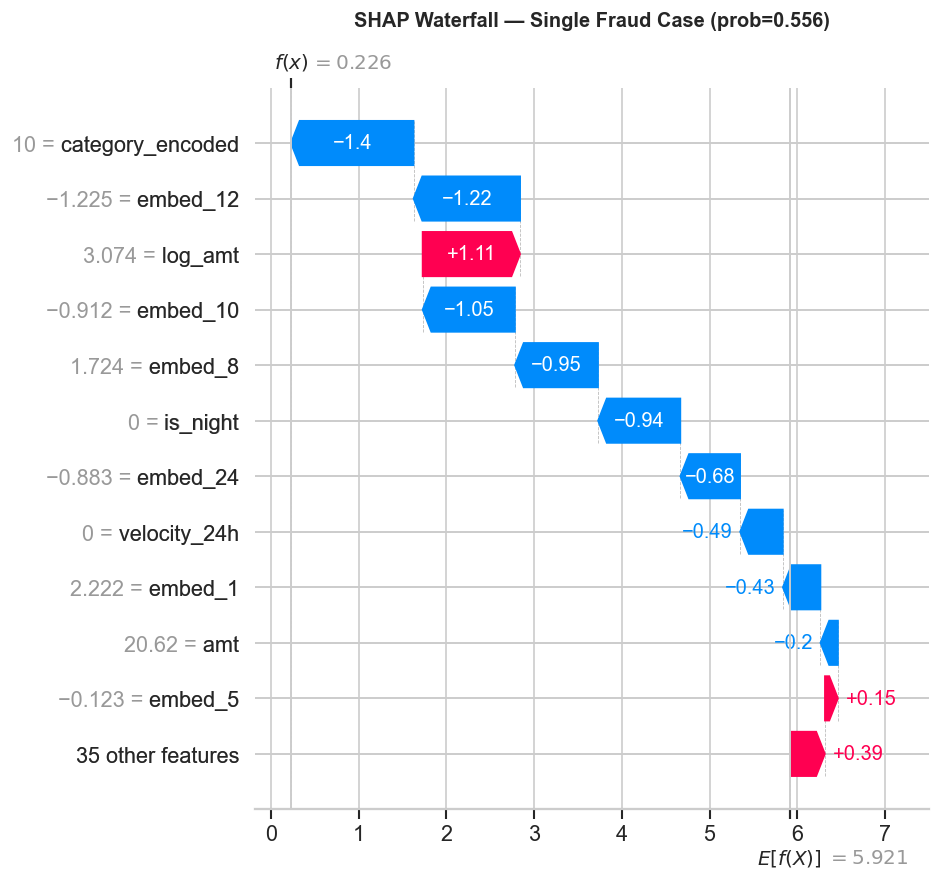

Saved: plot_shap_waterfall.png


In [37]:
fraud_positions = np.where(y_test.values == 1)[0]
fraud_pos       = fraud_positions[0]
fraud_row       = X_test.iloc[[fraud_pos]]

shap_single = explainer.shap_values(fraud_row)[0]

explanation = shap.Explanation(
    values        = shap_single,
    base_values   = explainer.expected_value,
    data          = fraud_row.iloc[0].values,
    feature_names = X_test.columns.tolist()
)

predicted_prob = float(xgb_model.predict_proba(fraud_row)[0, 1])
print(f'Transaction: FRAUD | Predicted probability: {predicted_prob:.4f}')
print('\nTop features pushing TOWARD fraud:')
contrib = pd.Series(shap_single, index=X_test.columns).sort_values(ascending=False)
print(contrib.head(5).to_string())

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation, show=False, max_display=12)
plt.title(f'SHAP Waterfall — Single Fraud Case (prob={predicted_prob:.3f})', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_shap_waterfall.png')

### How to read the SHAP waterfall plot

This chart explains **one individual fraud transaction** from the test set, feature by feature.

**E[f(x)]** (bottom bar) = the base value — the model's average output across all training data. For a fraud model this is a low number close to 0, reflecting that most transactions are legitimate.

**f(x)** (top) = the final predicted fraud probability for *this specific transaction*.

**Each bar** = one feature's contribution to moving the prediction from the base value to the final value:  
- **Red bars** push the prediction *toward fraud* (increase probability)  
- **Blue bars** push it *toward legitimate* (decrease probability)  
- Bar width = magnitude of the contribution

**What this means in fraud ops:**  
This is exactly what a case review tool shows an analyst — not just 'the model scored this 0.56' but *why*: 'this transaction was flagged primarily because the log-transformed amount was unusually high (+1.11 SHAP), with additional contributions from the FinBERT merchant embedding features (`embed_5`, `embed_11`, `embed_29`) and the cardholder's age profile.' That narrative is actionable — an analyst can verify each signal independently.

At Stripe, the difference between a black-box score and an explainable risk signal is the difference between an analyst accepting a decision and an analyst challenging it. SHAP makes the model auditable.

## Cell 10 — Final Summary

In [38]:
print('=' * 55)
print('FINAL MODEL SUMMARY — XGBoost Fraud Classifier')
print('=' * 55)
print(f'PR-AUC (PRIMARY): {pr_auc_xgb:.4f}')
print(f'ROC-AUC:          {roc_auc_xgb:.4f}')
print(f'F1:               {f1_xgb:.4f}')
print(f'Precision:        {prec_xgb:.4f}')
print(f'Recall:           {rec_xgb:.4f}')
print(f'\nTop 10 features by mean |SHAP|:')
for i, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    print(f'  {i:2}. {feat:<25} {val:.5f}')
print(f'\nModel:   models/xgb_fraud_model.pkl')
print(f'MLflow:  {MLFLOW_DB}')
print(f'Run ID:  {RUN_ID}')
print('=' * 55)
print('\nTo open MLflow UI — run in a NEW terminal from the project root:')
print('  mlflow ui --backend-store-uri sqlite:///mlflow.db')

FINAL MODEL SUMMARY — XGBoost Fraud Classifier
PR-AUC (PRIMARY): 0.8462
ROC-AUC:          0.9966
F1:               0.1738
Precision:        0.0953
Recall:           0.9890

Top 10 features by mean |SHAP|:
   1. amt                       3.31275
   2. log_amt                   1.57080
   3. category_encoded          1.13723
   4. is_night                  0.80351
   5. embed_7                   0.52635
   6. embed_1                   0.47232
   7. embed_0                   0.45410
   8. embed_9                   0.35282
   9. embed_11                  0.34248
  10. embed_5                   0.31380

Model:   models/xgb_fraud_model.pkl
MLflow:  C:\Users\34673\OneDrive\IRONHACK BOOTCAMP1\EXERCISES\WEEK8\PROJECT_FRAUD_DETECTION\fraud-detection-project\mlflow.db
Run ID:  133147dad1e74bfbbec07555524eae28

To open MLflow UI — run in a NEW terminal from the project root:
  mlflow ui --backend-store-uri sqlite:///mlflow.db


In [39]:
# Save Phase 4a metrics to JSON so notebook 04b can load them automatically
# This avoids manually copying numbers between notebooks
import json as _json

phase4a_metrics = {
    "lr": {
        "pr_auc":    round(float(pr_auc_lr),  6),
        "roc_auc":   round(float(roc_auc_lr), 6),
        "f1":        round(float(f1_lr),       6),
        "precision": round(float(prec_lr),     6),
        "recall":    round(float(rec_lr),      6)
    },
    "xgb": {
        "pr_auc":    round(float(pr_auc_xgb),  6),
        "roc_auc":   round(float(roc_auc_xgb), 6),
        "f1":        round(float(f1_xgb),       6),
        "precision": round(float(prec_xgb),     6),
        "recall":    round(float(rec_xgb),      6)
    }
}

metrics_path = DATA_PROCESSED / "phase4a_metrics.json"
with open(metrics_path, "w") as _f:
    _json.dump(phase4a_metrics, _f, indent=2)

print(f"Phase 4a metrics saved to: {metrics_path}")
print(f'  LR  -> PR-AUC: {phase4a_metrics["lr"]["pr_auc"]:.4f}  | ROC-AUC: {phase4a_metrics["lr"]["roc_auc"]:.4f}')
print(f'  XGB -> PR-AUC: {phase4a_metrics["xgb"]["pr_auc"]:.4f}  | ROC-AUC: {phase4a_metrics["xgb"]["roc_auc"]:.4f}')
print("Notebook 04b will load this file automatically in Cell 12.")

Phase 4a metrics saved to: ..\data\processed\phase4a_metrics.json
  LR  -> PR-AUC: 0.2387  | ROC-AUC: 0.9023
  XGB -> PR-AUC: 0.8462  | ROC-AUC: 0.9966
Notebook 04b will load this file automatically in Cell 12.


## Cell 11 — SQLite Predictions Database
This satisfies the optional SQL component of the bootcamp requirements.

**What this represents in a real system:** Every model decision is written to a database — the audit trail fraud ops agents and compliance teams query. At Stripe, this ledger feeds agent review queues, dashboards, and model monitoring.

In [40]:
conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.executescript('''
    DROP TABLE IF EXISTS predictions;
    DROP TABLE IF EXISTS model_runs;

    CREATE TABLE predictions (
        trans_index     INTEGER,
        actual_label    INTEGER,
        predicted_prob  REAL,
        predicted_label INTEGER,
        correct         INTEGER
    );

    CREATE TABLE model_runs (
        run_id      TEXT,
        model_name  TEXT,
        pr_auc      REAL,
        roc_auc     REAL,
        f1_score    REAL,
        n_train     INTEGER,
        n_test      INTEGER,
        timestamp   TEXT
    );
''')

predictions_rows = [
    (int(i), int(a), float(p), int(pr), int(a == pr))
    for i, (a, p, pr) in enumerate(zip(y_test.values, y_prob_xgb, y_pred_xgb))
]
cursor.executemany('INSERT INTO predictions VALUES (?,?,?,?,?)', predictions_rows)

cursor.execute('INSERT INTO model_runs VALUES (?,?,?,?,?,?,?,?)', (
    RUN_ID, 'XGBoost',
    round(pr_auc_xgb, 6), round(roc_auc_xgb, 6), round(f1_xgb, 6),
    len(X_train_sm), len(X_test),
    datetime.datetime.now().isoformat()
))
conn.commit()

print(f'Database: {DB_PATH}')
print(f'Predictions written: {len(predictions_rows):,}')

print('\n── Query 1: Fraud correctly caught ──')
q1 = cursor.execute('''
    SELECT
        SUM(CASE WHEN actual_label=1 AND correct=1 THEN 1 ELSE 0 END) AS true_positives,
        SUM(CASE WHEN actual_label=1 THEN 1 ELSE 0 END) AS total_fraud,
        ROUND(100.0*SUM(CASE WHEN actual_label=1 AND correct=1 THEN 1 ELSE 0 END)
              /SUM(CASE WHEN actual_label=1 THEN 1 ELSE 0 END),2) AS recall_pct
    FROM predictions
''').fetchone()
print(f'  Fraud caught: {q1[0]:,} / {q1[1]:,} ({q1[2]}% recall)')

print('\n── Query 2: Avg predicted probability by class ──')
for row in cursor.execute('''
    SELECT actual_label, ROUND(AVG(predicted_prob),4), COUNT(*)
    FROM predictions GROUP BY actual_label
''').fetchall():
    label = 'Fraud' if row[0]==1 else 'Legitimate'
    print(f'  {label:<12}: avg prob={row[1]:.4f}  n={row[2]:,}')

print('\n── Query 3: Model runs by PR-AUC ──')
for row in cursor.execute('''
    SELECT model_name, ROUND(pr_auc,4), ROUND(roc_auc,4), ROUND(f1_score,4), n_train
    FROM model_runs ORDER BY pr_auc DESC
''').fetchall():
    print(f'  {row[0]} | PR-AUC={row[1]} | ROC-AUC={row[2]} | F1={row[3]} | trained on {row[4]:,} rows')

conn.close()
print(f'\nDatabase saved: {DB_PATH}')

Database: ..\data\fraud_predictions.db
Predictions written: 259,335

── Query 1: Fraud correctly caught ──
  Fraud caught: 1,535 / 1,552 (98.9% recall)

── Query 2: Avg predicted probability by class ──
  Legitimate  : avg prob=0.0840  n=257,783
  Fraud       : avg prob=0.9786  n=1,552

── Query 3: Model runs by PR-AUC ──
  XGBoost | PR-AUC=0.8462 | ROC-AUC=0.9966 | F1=0.1738 | trained on 2,062,772 rows

Database saved: ..\data\fraud_predictions.db


### What these SQL queries show

**Query 1 — Fraud correctly caught (Recall)**  
This is your recall expressed as a raw count: how many of the test set's actual fraud transactions did XGBoost flag? The percentage matches the recall metric from Cell 6. In ops terms, this is the fraction of fraud cases that entered the analyst review queue rather than slipping through as chargebacks.

**Query 2 — Average predicted probability by class**  
- **Legitimate transactions:** average predicted fraud probability is very low (near 0) — the model is confidently clearing the vast majority of transactions  
- **Fraud transactions:** average predicted probability is high — the model assigns high risk to actual fraud  
A large gap between these two averages is the sign of a well-separated model. If the averages were close together, the model would be uncertain and useless at any threshold.

**Query 3 — Model runs table**  
Every time you retrain, a new row is written here with the run ID, metrics, and timestamp. In a production fraud system this table feeds model governance — compliance teams query which model version was active on any given date and what its performance was. This is not optional in a regulated payments environment.

**Why this matters for the presentation:**  
This satisfies the optional SQL requirement, but it also demonstrates something real: in production, every model decision is logged. Regulators, ops managers, and compliance teams all query tables like this. Building the habit of logging predictions is production-grade thinking.